---
Phase 5-Transformer-2: GPT 從零搭建 — Decoder-Only Transformer
---

GPT = Generative Pre-trained Transformer
  - Generative: 一個字一個字地「生成」
  - Pre-trained: 在大量文字上預訓練
  - Transformer: 基於 Transformer Decoder

本檔涵蓋：
  1. Causal Self-Attention（只看過去）
  2. GPT Block
  3. 完整的 MiniGPT 模型
  4. 文字生成（Temperature / Top-k / Top-p）
  5. 在字元級任務上訓練

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

# ============================================================================
# 1. Causal Self-Attention
# ============================================================================

In [2]:
print("=" * 60)
print("1. Causal Self-Attention — 看不到未來")
print("=" * 60)

print("""
GPT 在生成時是「從左到右」一個字一個字產生的：
  "The" → "cat" → "sat" → "on" → "the" → "mat"

所以位置 t 只能看到位置 0, 1, ..., t（不能偷看未來）

做法：用一個下三角 mask

  Attention scores:
  [✓  ✗  ✗  ✗]      加 mask 後:
  [✓  ✓  ✗  ✗]      [-∞ 變成 0 after softmax]
  [✓  ✓  ✓  ✗]
  [✓  ✓  ✓  ✓]
""")


class CausalSelfAttention(nn.Module):
    """GPT 的核心：Masked Multi-Head Attention"""
    def __init__(self, d_model, num_heads, max_len=512, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        # 預先建立 causal mask
        mask = torch.tril(torch.ones(max_len, max_len))
        self.register_buffer('mask', mask.view(1, 1, max_len, max_len))

    def forward(self, x):
        B, T, C = x.shape

        # 一次算出 Q, K, V
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.d_k)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, T, d_k)
        Q, K, V = qkv[0], qkv[1], qkv[2]

        # Scaled Dot-Product Attention
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Causal mask
        scores = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))

        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        out = weights @ V  # (B, heads, T, d_k)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out)


# 測試
attn = CausalSelfAttention(d_model=32, num_heads=4)
x = torch.randn(2, 6, 32)
out = attn(x)
print(f"Causal Self-Attention: {x.shape} → {out.shape}")

1. Causal Self-Attention — 看不到未來

GPT 在生成時是「從左到右」一個字一個字產生的：
  "The" → "cat" → "sat" → "on" → "the" → "mat"

所以位置 t 只能看到位置 0, 1, ..., t（不能偷看未來）

做法：用一個下三角 mask

  Attention scores:
  [✓  ✗  ✗  ✗]      加 mask 後:
  [✓  ✓  ✗  ✗]      [-∞ 變成 0 after softmax]
  [✓  ✓  ✓  ✗]
  [✓  ✓  ✓  ✓]

Causal Self-Attention: torch.Size([2, 6, 32]) → torch.Size([2, 6, 32])


## 2. GPT Block

In [3]:
print("\n" + "=" * 60)
print("2. GPT Block")
print("=" * 60)

print("""
GPT Block (Pre-Norm):
  x → LayerNorm → Causal Attention → (+x)
                                       ↓
  → LayerNorm → FFN → (+x) → output
""")


class GPTBlock(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, num_heads, dropout=dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


2. GPT Block

GPT Block (Pre-Norm):
  x → LayerNorm → Causal Attention → (+x)
                                       ↓
  → LayerNorm → FFN → (+x) → output



## 3. 完整的 MiniGPT

In [4]:
print("\n" + "=" * 60)
print("3. MiniGPT — 完整模型")
print("=" * 60)


class MiniGPT(nn.Module):
    """
    一個完整但精簡的 GPT 模型

    架構：
      Token Embedding + Position Embedding
      → N × GPT Block
      → LayerNorm → Linear (vocab_size)
    """
    def __init__(self, vocab_size, d_model=64, num_heads=4,
                 num_layers=4, max_len=128, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        self.blocks = nn.Sequential(
            *[GPTBlock(d_model, num_heads, dropout) for _ in range(num_layers)]
        )

        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        # weight tying: embedding 和 output 共用權重
        self.head.weight = self.token_emb.weight

        self.max_len = max_len
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0, std=0.02)

    def forward(self, idx, targets=None):
        """
        idx: (batch, seq_len) token indices
        targets: (batch, seq_len) 下一個 token 的 index（訓練用）
        """
        B, T = idx.shape
        assert T <= self.max_len

        # Embeddings
        tok_emb = self.token_emb(idx)             # (B, T, d_model)
        pos_emb = self.pos_emb(torch.arange(T, device=idx.device))  # (T, d_model)
        x = tok_emb + pos_emb

        # Transformer blocks
        x = self.blocks(x)
        x = self.ln_f(x)

        # Language model head
        logits = self.head(x)                      # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """自迴歸生成"""
        for _ in range(max_new_tokens):
            # 如果超過 max_len，截斷
            idx_cond = idx[:, -self.max_len:]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature   # 只看最後一步

            # Top-k filtering
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_token], dim=1)

        return idx


# 建立模型
model = MiniGPT(vocab_size=256, d_model=64, num_heads=4, num_layers=4, max_len=128)
total_params = sum(p.numel() for p in model.parameters())
print(f"MiniGPT:")
print(f"  vocab_size=256, d_model=64, heads=4, layers=4")
print(f"  參數量: {total_params:,}")
print(f"\n  對比:")
print(f"  GPT-2 Small:  124M 參數 (d=768,  12 layers, 12 heads)")
print(f"  GPT-2 Medium: 355M 參數 (d=1024, 24 layers, 16 heads)")
print(f"  GPT-3:        175B 參數 (d=12288, 96 layers, 96 heads)")
print(f"  LLaMA-7B:     7B 參數   (d=4096, 32 layers, 32 heads)")

# 測試前向傳播
idx = torch.randint(0, 256, (2, 20))
logits, loss = model(idx, targets=idx)
print(f"\n前向傳播:")
print(f"  輸入: {idx.shape}")
print(f"  logits: {logits.shape}")


3. MiniGPT — 完整模型
MiniGPT:
  vocab_size=256, d_model=64, heads=4, layers=4
  參數量: 224,640

  對比:
  GPT-2 Small:  124M 參數 (d=768,  12 layers, 12 heads)
  GPT-2 Medium: 355M 參數 (d=1024, 24 layers, 16 heads)
  GPT-3:        175B 參數 (d=12288, 96 layers, 96 heads)
  LLaMA-7B:     7B 參數   (d=4096, 32 layers, 32 heads)

前向傳播:
  輸入: torch.Size([2, 20])
  logits: torch.Size([2, 20, 256])


## 4. 生成策略


4. 生成策略 — Temperature / Top-k / Top-p

生成時的三個關鍵參數：

  1. Temperature (T):
     logits = logits / T
     T=1.0: 正常
     T<1.0: 更確定（保守、重複）
     T>1.0: 更隨機（創意、可能亂講）

  2. Top-k:
     只從機率最高的 k 個 token 中抽樣
     k=1: greedy（永遠選最大的）
     k=50: 從前 50 個中隨機選

  3. Top-p (nucleus sampling):
     動態選擇 token 數量
     從機率高的開始累積，直到總機率 >= p
     p=0.9: 可能只選前幾個，也可能選很多個



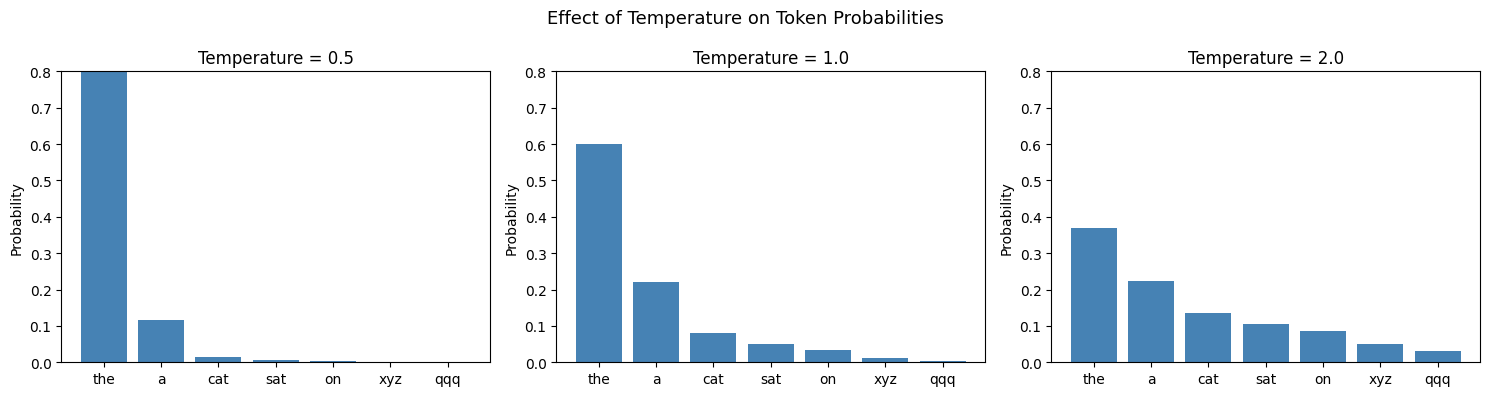

→ 圖表儲存至 transformer/plots/02_temperature.png


In [5]:
print("\n" + "=" * 60)
print("4. 生成策略 — Temperature / Top-k / Top-p")
print("=" * 60)

print("""
生成時的三個關鍵參數：

  1. Temperature (T):
     logits = logits / T
     T=1.0: 正常
     T<1.0: 更確定（保守、重複）
     T>1.0: 更隨機（創意、可能亂講）

  2. Top-k:
     只從機率最高的 k 個 token 中抽樣
     k=1: greedy（永遠選最大的）
     k=50: 從前 50 個中隨機選

  3. Top-p (nucleus sampling):
     動態選擇 token 數量
     從機率高的開始累積，直到總機率 >= p
     p=0.9: 可能只選前幾個，也可能選很多個
""")

# 視覺化 temperature 的效果
logits = torch.tensor([3.0, 2.0, 1.0, 0.5, 0.1, -1.0, -2.0])
tokens = ['the', 'a', 'cat', 'sat', 'on', 'xyz', 'qqq']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, temp in enumerate([0.5, 1.0, 2.0]):
    probs = F.softmax(logits / temp, dim=0).numpy()
    axes[i].bar(tokens, probs, color='steelblue')
    axes[i].set_title(f'Temperature = {temp}')
    axes[i].set_ylabel('Probability')
    axes[i].set_ylim(0, 0.8)

plt.suptitle('Effect of Temperature on Token Probabilities', fontsize=13)
plt.tight_layout()
plt.savefig('phase-5-modern/transformer/plots/02_temperature.png', dpi=100)
plt.show()
print("→ 圖表儲存至 transformer/plots/02_temperature.png")

## 5. 在字元級任務上訓練


5. 訓練 MiniGPT — 字元級語言模型
字元數: 26
字元: 
 .abcdefghijklmnoprstuvwy
資料長度: 350 字元



MiniGPT 參數量: 103,808
  Step     Loss
----------------


     0   3.2647


   100   1.0788


   200   0.4025


   300   0.2346


   400   0.2025


   499   0.1689

--- 生成文字 ---
  T=0.5: "the cat.
a cat likes fish. a dog likes meat.
the cat is s"


  T=0.8: "the cat sat on the mat. the dog sat on the rug.
the cat c"
  T=1.0: "the cat sat on the mat. the dog sat on the rug.
the cat c"


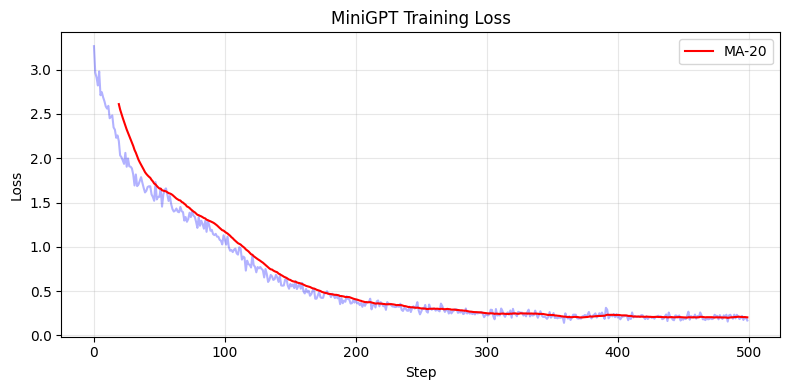


→ 圖表儲存至 transformer/plots/02_training_loss.png


In [6]:
print("\n" + "=" * 60)
print("5. 訓練 MiniGPT — 字元級語言模型")
print("=" * 60)

# 用一段簡單的文字訓練
text = """the cat sat on the mat. the dog sat on the rug.
the cat chased the dog. the dog chased the cat.
a cat likes fish. a dog likes meat.
the cat is small and cute. the dog is big and strong.
the cat sat on the mat again. the dog ran in the park.
cats and dogs are both pets. they like to play together.
the small cat jumped over the big dog. it was funny."""

# 字元級 tokenizer
chars = sorted(set(text))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(chars)
print(f"字元數: {vocab_size}")
print(f"字元: {''.join(chars)}")

# 編碼
data = torch.tensor([char2idx[c] for c in text], dtype=torch.long)
print(f"資料長度: {len(data)} 字元")

# 準備訓練資料
block_size = 32  # 上下文長度


def get_batch(data, batch_size, block_size):
    starts = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[s:s+block_size] for s in starts])
    y = torch.stack([data[s+1:s+block_size+1] for s in starts])
    return x, y


# 訓練
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MiniGPT(
    vocab_size=vocab_size, d_model=64, num_heads=4,
    num_layers=2, max_len=block_size, dropout=0.1,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
data = data.to(device)

print(f"\nMiniGPT 參數量: {sum(p.numel() for p in model.parameters()):,}")
print(f"{'Step':>6} {'Loss':>8}")
print("-" * 16)

losses = []
for step in range(500):
    x, y = get_batch(data, batch_size=16, block_size=block_size)
    logits, loss = model(x, targets=y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if step % 100 == 0:
        print(f"{step:6d} {loss.item():8.4f}")

print(f"{499:6d} {losses[-1]:8.4f}")

# 生成
model.eval()
print("\n--- 生成文字 ---")
for temp in [0.5, 0.8, 1.0]:
    start = torch.tensor([char2idx[c] for c in "the cat"], device=device).unsqueeze(0)
    generated = model.generate(start, max_new_tokens=50, temperature=temp)
    text_out = ''.join([idx2char[i.item()] for i in generated[0]])
    print(f"  T={temp}: \"{text_out}\"")

# 畫 loss 曲線
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, alpha=0.3, color='blue')
# 移動平均
window = 20
if len(losses) > window:
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(losses)), smoothed, color='red', label=f'MA-{window}')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('MiniGPT Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-5-modern/transformer/plots/02_training_loss.png', dpi=100)
plt.show()
print("\n→ 圖表儲存至 transformer/plots/02_training_loss.png")

## 小結

In [7]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
GPT 的核心架構：

  Token Embedding + Position Embedding
  → N × [LayerNorm → Causal Attention → (+) → LayerNorm → FFN → (+)]
  → LayerNorm → Linear → logits

  訓練目標：預測下一個 token
    Loss = CrossEntropy(logits[t], actual_token[t+1])

  生成：自迴歸
    "The" → model → "cat"
    "The cat" → model → "sat"
    "The cat sat" → model → "on"
    ...

  關鍵設計：
  1. Causal Mask: 看不到未來
  2. Weight Tying: embedding 和 output 共用
  3. Pre-Norm: LayerNorm 在 attention/FFN 前面
  4. GELU: 比 ReLU 更平滑

  Scaling Law:
  模型越大 + 資料越多 + 算力越多 → 效果越好
  這就是為什麼大家都在拼命做更大的模型！

下一步：llm/01_tokenization.py — Tokenization 技術
""")


小結

GPT 的核心架構：

  Token Embedding + Position Embedding
  → N × [LayerNorm → Causal Attention → (+) → LayerNorm → FFN → (+)]
  → LayerNorm → Linear → logits

  訓練目標：預測下一個 token
    Loss = CrossEntropy(logits[t], actual_token[t+1])

  生成：自迴歸
    "The" → model → "cat"
    "The cat" → model → "sat"
    "The cat sat" → model → "on"
    ...

  關鍵設計：
  1. Causal Mask: 看不到未來
  2. Weight Tying: embedding 和 output 共用
  3. Pre-Norm: LayerNorm 在 attention/FFN 前面
  4. GELU: 比 ReLU 更平滑

  Scaling Law:
  模型越大 + 資料越多 + 算力越多 → 效果越好
  這就是為什麼大家都在拼命做更大的模型！

下一步：llm/01_tokenization.py — Tokenization 技術

